# MST Topology Trading Strategy — Project Proposal

**Zara Nip** | Student ID: **12411910**

**Aryaa Gunavante** | Student ID:**12496718**

**Gabriella Wiem** | Student ID:**12506599**

**Hsiao-Chi Chen** | Student ID: **12498162**

**Shreya Enaganti**| Student ID:**12506493**

FINM — Quantitative Trading Strategies | Winter 2026

## 1. Project Motivation

Financial markets are commonly studied as collections of individual assets whose prices follow their own stochastic processes. In practice, however, returns are driven by shared exposures, such as interest-rate regimes, risk-appetite shifts, and supply shocks. These events, along with the several inherent characteristics of assets, induce complex, time-varying dependency structures within and across asset classes. 

Often, a standard correlation matrix is utilized to capture pairwise linear comovement. Though a powerful tool on its own, its simplicity overlooks relationship-specific behaviors and treats every pair of assets symmetrically and independently, providing no notion of which linkages are structurally dominant versus redundant.

We address this limitation by applying a graph-theoretic lens to the correlation matrix. Specifically, we convert rolling pairwise correlations into a metric distance (Mantegna, 1999), which is used to construct a minimum spanning tree (MST). This tree represents a unique connected weighted subgraph that links all the assets in our universe, providing a minimum total distance between each pair. The MST provides a skeleton of the market's dependency structure, discarding redundant connections that would otherwise serve to add noise. 

The project studies whether temporary dislocations in the MST's topology provide profitable tradeable signals. We are specifically interested in whether anomalous changes in the effective resistance between adjacent assets on the tree, defined as the cumulative sum of edge weights along the unique path connecting two nodes, is predictive of short-horizon mean reversion in relative returns. 

Our hypothesis is grounded in simple economic intuition: when two assets that tend to move together suddenly decouple on the network, the deviation is more likely to reverse than to persist. This operates on the assumption that the underlying structural relationship observed over a rolling window has not permanently changed.

The approach we take is distinguished from standard correlation-based pair trading in three ways: 
1. **Topological selection:** We only trade pairs that are identified as neighbors on the MST. The tree enforces sparsity and ensures that each pair carries non-redundant information about market structure. 
2. **Path-aware dislocation measurement:** Effective resistance, also known as the Kirchhoff distance, is utilized to determine the strength of connections between two non-adjacent nodes; we compute this metric for two non-adjacent nodes by calculating the sum of the weights on the path from one to another. Two assets can have moderate direct correlation but low effective resistance if they are connected through a short, tight chain of intermediaries, or vice versa. 
3. **Regime-adaptive risk scaling:** The Fiedler value, given by the second smallest eigenvalue of the MST's Laplacian, measures how tightly the market is coupled at any point in time. When this value drops below its historical norm, the network is fragmenting overall, and mean reversion becomes less reliable. In periods where the Fiedler value increases--indicating a tightly coupled, crisis-like regime in which systemic stress rises and cross-asset correlations intensify--the strategy automatically reduces gross exposure to mitigate the heightened risk of synchronized market moves.

## 2. Mathematical and Theoretical Foundation

We construct the strategy by embedding financial returns into a metric space, extracting a sparse structural representation, and measuring deviations from that structure through spectral graph theory.

The mathematical pipeline proceeds in four steps:

1. We first convert correlations into a Euclidean metric representation of assets.
2. We then construct the minimum spanning tree to isolate the dominant dependency backbone.
3. From this tree, we derive the Laplacian operator and compute effective resistance to measure structural separation between each asset.
4. We subsequently analyze the Laplacian spectrum to obtain algebraic connectivity as an indicator of systemic integration.

Each step introduces a well-defined mathematical object with economic interpretation.

### 2.1 From Correlation to a Metric Space 

First, we begin with the Pearson correlation matrix of asset returns. Let $r_i(t)$ denote log returns. Define the Pearson correlation over a rolling window:

$$
\rho_{ij} = 
\frac{\mathbb{E}[r_i r_j] - \mathbb{E}[r_i]\mathbb{E}[r_j]}
{\sigma_i \sigma_j}.
$$

While correlation measures linear dependence, it does not define a proper geometric distance. To obtain a true metric space, we apply the nonlinear transformation. Per Mantegna (1999), we have the metric $d_{ij} = \sqrt{2(1 - \rho_{ij})}$, which represents the Euclidean separation between assets $i$ and $j$. With this metric, we observe that low correlation between assets $i$ and $j$ results in a larger geometric distance, $d_{ij}$, and vice versa. Assets that load on similar economic factors become geometrically close; assets driven by unrelated or opposing factors become far apart.



### 2.2 From the Metric Space to Minimum Spanning Tree 

Consider the complete weighted graph $G = (V, E, d_{ij})$ with $N$ nodes and $\binom{N}{2}$ edges. We construct the minimum spanning tree (MST), defined as $T = \arg\min_{T \subset G} \sum_{(i,j)\in T} d_{ij}$. This is the unique connected, acyclic subgraph that links all assets while minimizing the total metric length. By selecting only $N-1$ edges by use of Kruskal's algorithm, the MST extracts the sparsest structure that preserves global connectivity. This process filters out redundant correlations and isolates the dominant dependency backbone of the market. Economically, this backbone can be interpreted as the dominant channels through which common shocks and factor exposures propagate. Assets that are close in the tree share strong primary dependencies, and assets connected only through longer chains share weaker or more indirect exposure.

### 2.3 Graph Laplacian and Effective Resistance

Given the minimum spanning tree $T$, we encode its topology in matrix form through the graph Laplacian. Let $A$ denote the weighted adjacency matrix of the tree and let $D$ be the diagonal degree matrix with entries $D_{ii} = \sum_j A_{ij}$. The (weighted) Laplacian is defined as $L = D - A$, and it summarizes how variation propagates across nodes. 

From the Laplacian, we compute the effective resistance (Klein & Randić, 1993). Formally, the effective resistance between nodes $i$ and $j$ is
$$
\Omega_{ij} = (e_i - e_j)^T L^{\dagger} (e_i - e_j),
$$
where $L^{\dagger}$ is the Moore–Penrose pseudoinverse.

On a tree, there exists exactly one simple path between any two nodes. In this case, effective resistance reduces to the cumulative sum of edge weights along that path: $\Omega_{ij} = \sum_{(k,\ell)\in \text{path}(i,j)} d_{k\ell}$. Therefore, on the MST, the effective resistance can be interpreted as providing a path-aware structural distance. Unlike raw correlation, which measures only local pairwise dependence, effective resistance aggregates the entire sequence of dependencies linking two assets through intermediary nodes. The metric essentially quantifies structural separation within the market backbone, where assets with short chains are characterized by low resistance, while assets separated by long chains have high resistance.


### 2.4 Spectral Decomposition and Algebraic Connectivity

Applying eigen-decomposition to the Laplacian gives us the second eigenvalue, termed the Fiedler value, denoted by $\lambda_2$. The Fiedler value measures the algebraic connectivity of the graph. Larger $\lambda_2$ values imply stronger connectivity and $\lambda_2 = 0$ if and only if the graph is disconnected. 

In the context of financial markets, $\lambda_2$ serves as a quantitative measure of systemic integration. When $\lambda_2$ increases, the network becomes more cohesive, indicating that assets are moving in a more synchronized manner. Empirical evidence in Onnela et al. (2003) shows that during market crises the minimum spanning tree becomes more compact and star-like, reflecting heightened cross-asset correlation and tighter structural coupling.

Similarly, Pozzi, Di Matteo, and Aste (2013) demonstrate that changes in network topology are closely linked to shifts in realized correlation and diversification potential. In highly integrated regimes, structural dispersion falls and relative-value relationships weaken.

Accordingly, we interpret elevated $\lambda_2$ values as indicative of tightly synchronized market states, often associated with systemic stress. In such regimes, mean-reversion across pairs becomes less reliable, motivating dynamic adjustment of gross exposure based on deviations of $\lambda_2$ from its historical norm.

### 2.5 Structural Signal Construction

...

By combining these ideas, we construct a complete signal pipeline: Mantegna distances → MST construction → effective resistance computation → z-score normalization → volatility-targeted pair sizing → Fiedler-based risk throttle.

## 3. Investment Universe

We select 21 highly liquid ETFs spanning four asset classes. The diversity ensures that the MST captures genuine cross-asset structure rather than within-sector correlation noise:

| Asset Class | ETFs | Count |
|---|---|---|
| Equity Sectors | XLF, XLK, XLE, XLV, XLI, XLY, XLP, XLB, XLU | 9 |
| Commodities | GLD, SLV, USO, DBA | 4 |
| Currencies | FXE, FXB, FXY, FXA | 4 |
| Fixed Income | TLT, IEF, HYG, LQD | 4 |

All data is sourced from **NASDAQ Data Link** via the QuoteMedia/PRICES table. We use adjusted close prices to account for splits and dividends, ensuring returns are computed on an apples-to-apples basis across the full sample.

The sample period runs from **January 2, 2018 through December 31, 2025**, providing nearly eight years of daily data that spans several distinct market regimes: the late bull market (2018-19), the COVID crash and recovery (2020), the post-pandemic inflation and rate-hiking cycle (2021-22), and the subsequent stabilization (2023-25). This variety is important for testing whether MST-based signals are robust across environments.

## 4. Data Acquisition and Cleaning

We now walk through the data pipeline: fetching prices from NASDAQ Data Link, caching them locally, constructing the return matrix, and verifying data integrity.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mst_strategy import load_or_fetch_prices, mantegna_distance, build_mst_kruskal

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

# ── Configuration ──
ETF_UNIVERSE = [
    'XLF', 'XLK', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLU',  # Equity sectors
    'GLD', 'SLV', 'USO', 'DBA',                                        # Commodities
    'FXE', 'FXB', 'FXY', 'FXA',                                        # Currencies
    'TLT', 'IEF', 'HYG', 'LQD',                                        # Fixed income
]

START_DATE = '2018-01-01'
END_DATE = '2025-12-31'
DATA_DIR = Path('data')

The cell below loads adjusted close prices from locally cached CSVs. If a ticker is missing from the cache, it fetches from NASDAQ Data Link via the `QUOTEMEDIA/PRICES` table and saves the result for future runs. This avoids hitting the API on every execution and makes the notebook reproducible without network access.

In [2]:
prices = load_or_fetch_prices(ETF_UNIVERSE, START_DATE, END_DATE, str(DATA_DIR))

print(f'Loaded price panel: {prices.shape[0]} trading days x {prices.shape[1]} assets')
print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Assets: {list(prices.columns)}')
prices.head()

Loaded price panel: 1862 trading days x 21 assets
Date range: 2018-01-02 to 2025-05-29
Assets: ['DBA', 'FXA', 'FXB', 'FXE', 'FXY', 'GLD', 'HYG', 'IEF', 'LQD', 'SLV', 'TLT', 'USO', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']


ticker,DBA,FXA,FXB,FXE,FXY,GLD,HYG,IEF,LQD,SLV,...,USO,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,17.6710,75.1934,124.8302,112.0236,85.4700,125.1500,62.9520,91.7215,98.1064,16.2100,...,96.5600,54.0963,55.0574,24.7029,67.9851,60.4606,47.7479,42.7125,75.2431,94.2526
2018-01-03,17.6617,75.2703,124.0650,111.5512,85.3000,124.8200,63.2547,91.8173,98.2851,16.1700,...,98.7200,54.4752,55.8819,24.8357,68.3513,60.9649,47.7310,42.3770,75.9631,94.6854
2018-01-04,17.6337,75.5487,124.4145,112.1104,85.1300,125.4600,63.3628,91.7738,98.2526,16.2300,...,98.9600,54.9510,56.2193,25.0657,68.8514,61.2731,47.8661,42.0251,76.0711,94.9958
2018-01-05,17.5406,75.5967,124.5468,111.8019,84.8400,125.3300,63.4061,91.6604,98.2201,16.2200,...,98.4800,55.3916,56.1968,25.1365,69.3248,61.9174,48.0773,42.0087,76.7190,95.7484
2018-01-08,17.4195,75.3087,124.5373,111.1271,84.8533,125.3100,63.3556,91.6169,98.2120,16.1500,...,99.0400,55.4709,56.5341,25.1011,69.6106,62.1509,48.1955,42.4015,76.4400,95.8613


### 4.1 Missing Data Check

For the MST construction to be valid, we need a complete, aligned panel — missing prices would produce unreliable correlations and distort the tree geometry. We check for gaps and verify the panel is dense enough for downstream analysis.

In [3]:
missing_by_ticker = prices.isna().sum()
total_missing = int(missing_by_ticker.sum())

print(f'Total missing values across the entire panel: {total_missing}')
if total_missing > 0:
    print('Missing values by ticker:')
    print(missing_by_ticker[missing_by_ticker > 0])
else:
    print('The panel is fully populated — no missing values detected.')

print(f'\nPanel density: {(1 - prices.isna().mean().mean()) * 100:.2f}%')

Total missing values across the entire panel: 0
The panel is fully populated — no missing values detected.

Panel density: 100.00%


### 4.2 Return Computation

We compute simple daily returns from adjusted close prices. The first row is dropped because it has no prior observation. We also compute basic summary statistics to confirm the data is sensible — typical daily moves should be on the order of tens of basis points to a few percent.

In [4]:
returns = prices.pct_change().dropna()

print(f'Return matrix: {returns.shape[0]} observations x {returns.shape[1]} assets')
print(f'Average daily absolute return across all assets: {returns.abs().mean().mean():.4f}')
print(f'Average daily return (annualized): {returns.mean().mean() * 252:.4f}')

return_stats = returns.describe().T[['mean', 'std', 'min', 'max']]
return_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
return_stats['Annualized Vol'] = return_stats['Std Dev'] * np.sqrt(252)
return_stats

Return matrix: 1861 observations x 21 assets
Average daily absolute return across all assets: 0.0079
Average daily return (annualized): 0.0688


,Mean,Std Dev,Min,Max,Annualized Vol
ticker,,,,,
DBA,0.0003,0.0088,-0.0486,0.0303,0.1389
FXA,-0.0001,0.0066,-0.0437,0.0299,0.1040
FXB,0.0000,0.0057,-0.0417,0.0320,0.0900
FXE,-0.0000,0.0046,-0.0206,0.0249,0.0738
FXY,-0.0001,0.0059,-0.0449,0.0405,0.0939
GLD,0.0005,0.0093,-0.0537,0.0485,0.1473
HYG,0.0001,0.0058,-0.0550,0.0655,0.0920
IEF,0.0000,0.0045,-0.0251,0.0264,0.0718
LQD,0.0001,0.0061,-0.0500,0.0739,0.0966


The summary statistics above confirm that our data is well-behaved. Daily means are close to zero (as expected for daily frequency), standard deviations vary meaningfully across asset classes — equities and commodities are more volatile than fixed income and currencies — and no extreme outliers suggest data errors. The annualized volatilities range from approximately 4-5% for short-duration bond ETFs to 30%+ for commodity-linked instruments like USO, which is consistent with known asset-class risk profiles.

## 5. Exploratory Data Analysis

Before constructing any signals, we examine three key properties of the data that are directly relevant to the strategy: (1) the cumulative return trajectories, which reveal whether the universe offers genuine cross-asset diversity; (2) the full-sample correlation structure, which motivates the MST filtering step; and (3) the rolling volatility dynamics, which affect the sizing and risk-management layers.

### Graph 1: Cumulative Returns by ETF

We plot cumulative returns for every ETF in the universe. A heterogeneous set of trajectories confirms that the universe is not dominated by a single factor and that the MST will capture meaningful cross-asset structure.

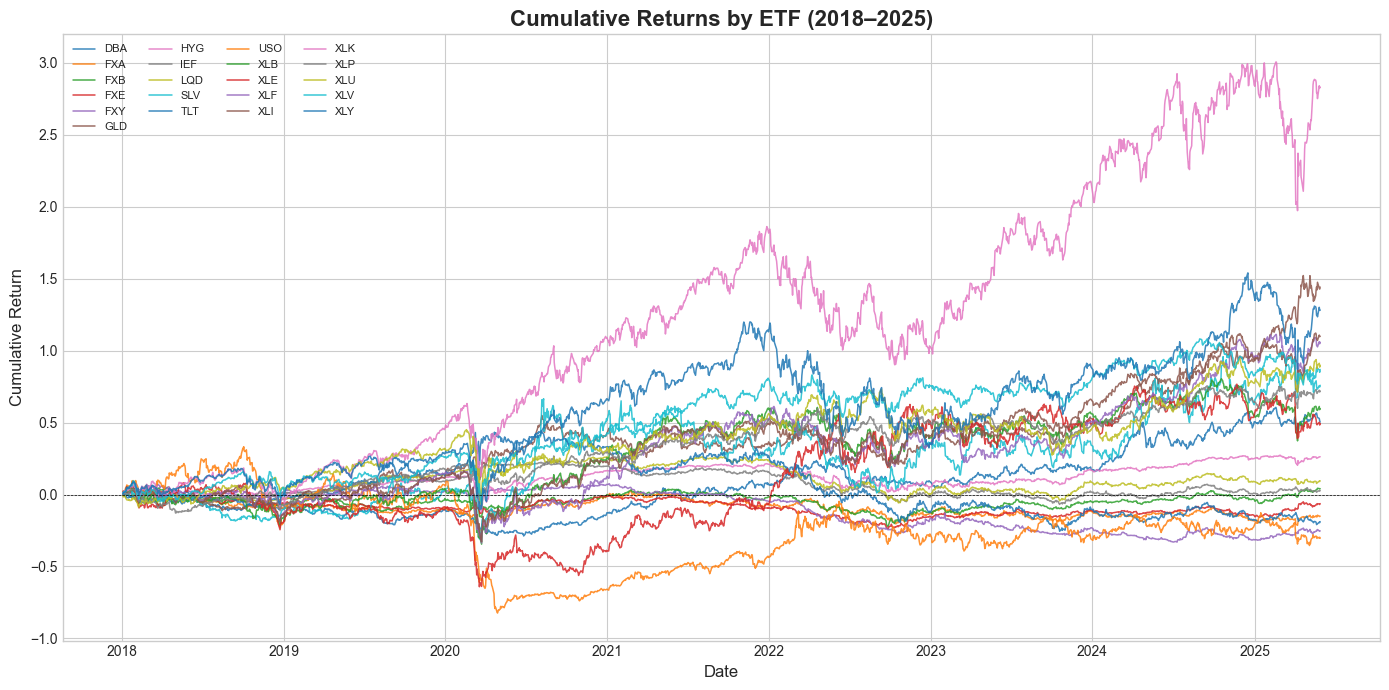

Highest cumulative return: XLK at 2.8311
Lowest cumulative return: USO at -0.3042
Cross-sectional dispersion (std of final cumulative returns): 0.7413


In [5]:
cum_returns = (1 + returns).cumprod() - 1

fig, ax = plt.subplots(figsize=(14, 7))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], linewidth=1.1, alpha=0.85, label=col)

ax.set_title('Cumulative Returns by ETF (2018–2025)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=4, framealpha=0.9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

total_cum = cum_returns.iloc[-1].sort_values(ascending=False)
print(f'Highest cumulative return: {total_cum.index[0]} at {total_cum.iloc[0]:.4f}')
print(f'Lowest cumulative return: {total_cum.index[-1]} at {total_cum.iloc[-1]:.4f}')
print(f'Cross-sectional dispersion (std of final cumulative returns): {total_cum.std():.4f}')

The wide dispersion in terminal cumulative returns — ranging from strongly positive (technology and equity growth sectors) to negative (energy-linked and some currency ETFs) — confirms that this is a heterogeneous opportunity set rather than a single-factor basket. The COVID drawdown in March 2020 is visible across most assets but affects them asymmetrically, which is exactly the kind of cross-asset structure the MST is designed to capture. The persistent divergence across asset classes supports the premise that tree-based filtering can isolate meaningful dependency channels.

Quantitatively, the spread between the best and worst performers is large: XLK finishes around +2.83 in cumulative return while USO ends near −0.30, implying a cross-asset range of roughly 3.1 in terminal outcomes. This dispersion is not just a visual impression — the cross-sectional standard deviation of terminal cumulative returns is about 0.74, which is sizeable relative to the typical 0–1 scale most lines occupy for much of the sample. In other words, even after aggregating seven years of returns, the universe does not “collapse” onto a tight band; it fans out materially, which is exactly the regime where a sparse representation like the MST is useful. 

### Graph 2: Full-Sample Correlation Heatmap

We compute the full-sample Pearson correlation matrix and visualize it as a heatmap. This motivates the MST filtering step: the raw correlation matrix has $21 \times 20 / 2 = 210$ unique pairwise relationships, most of which are noisy and redundant. The MST will retain only 20 edges.

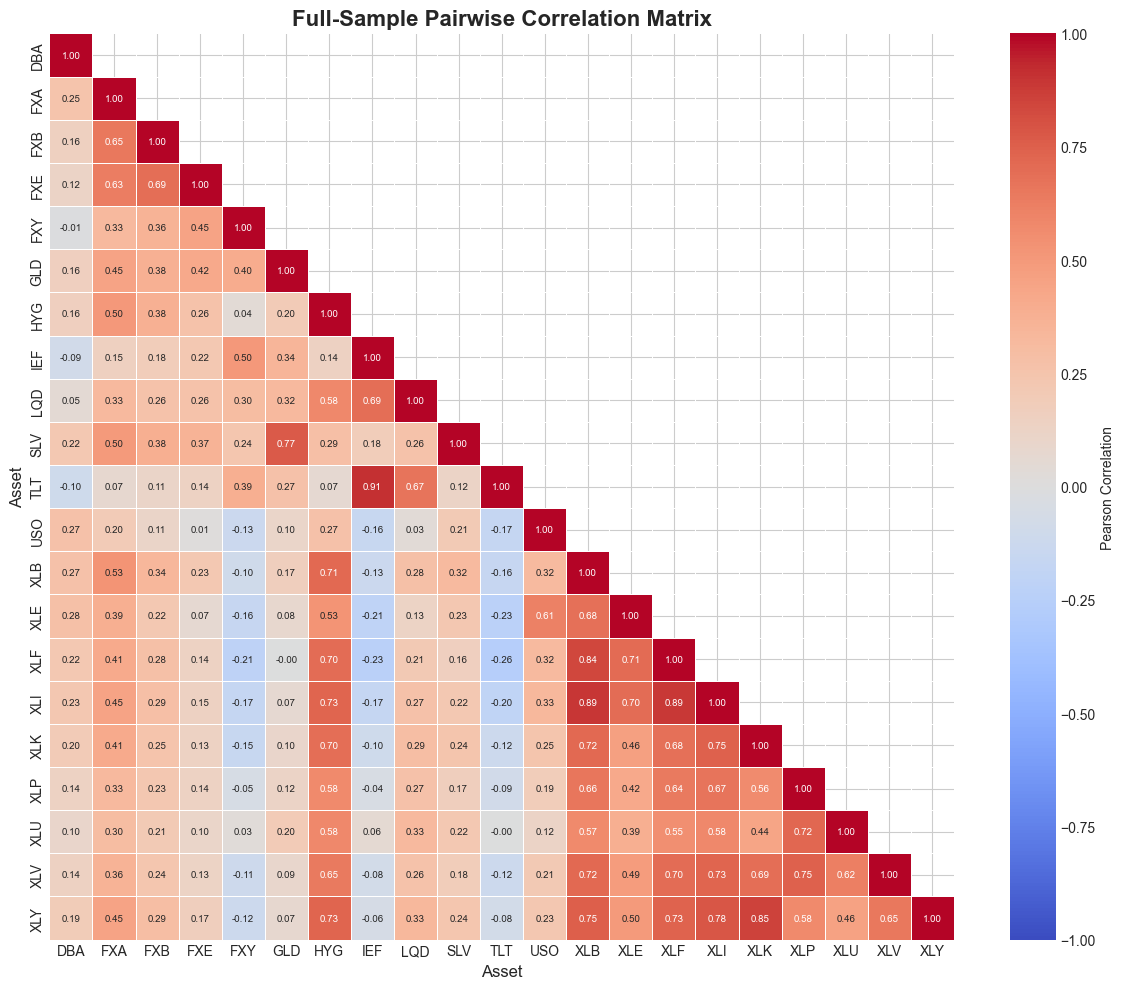

Average pairwise correlation: 0.2896
Minimum pairwise correlation: -0.2623
Maximum pairwise correlation: 0.9115
Share of pairs with |correlation| > 0.5: 23.81%


In [6]:
corr_full = returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
sns.heatmap(
    corr_full, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Full-Sample Pairwise Correlation Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Asset', fontsize=12)
ax.set_ylabel('Asset', fontsize=12)
plt.tight_layout()
plt.show()

upper_corr = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool)).stack()
print(f'Average pairwise correlation: {upper_corr.mean():.4f}')
print(f'Minimum pairwise correlation: {upper_corr.min():.4f}')
print(f'Maximum pairwise correlation: {upper_corr.max():.4f}')
print(f'Share of pairs with |correlation| > 0.5: {(upper_corr.abs() > 0.5).mean():.2%}')

The heatmap reveals a clear block structure: equity-sector ETFs form a warm cluster of positive correlations in the upper-left, while fixed-income instruments (TLT, IEF) show mild negative or near-zero correlation with equities. Commodities and currencies sit between these two clusters with moderate, mixed co-movements. Importantly, many off-diagonal correlations are non-zero but weak — exactly the kind of noisy, semi-redundant structure that the MST is designed to compress. By keeping only 20 of the 210 edges, the tree will isolate the strongest connectivity channels and discard the rest.

Quantitatively, the average pairwise correlation across the full universe is about 0.29, which means co-movement is present but far from uniform. The strongest pair reaches roughly 0.91 (a near “lockstep” relationship), while the most negative pair is only around −0.26, suggesting that truly strong structural hedges are rare in full-sample averages. Consistent with the visual block structure, only ~23.8% of pairs have |corr| > 0.5 — so roughly three-quarters of the matrix sits in the weak-to-moderate range where relationships are easy to over-interpret and highly redundant. That gap between a small set of very strong links and a large mass of marginal ones is exactly the setting where an MST is useful: it forces the network to express the dependency structure through a small number of high-signal edges and a handful of cross-cluster “bridges,” rather than spreading attention across hundreds of borderline correlations.

### Graph 3: Annualized Volatility by Asset

Understanding the volatility profile of each asset is critical because the strategy's pair weights are inversely proportional to spread volatility. Assets with very different risk profiles will produce pairs whose spread behavior — and therefore signal quality — varies substantially.

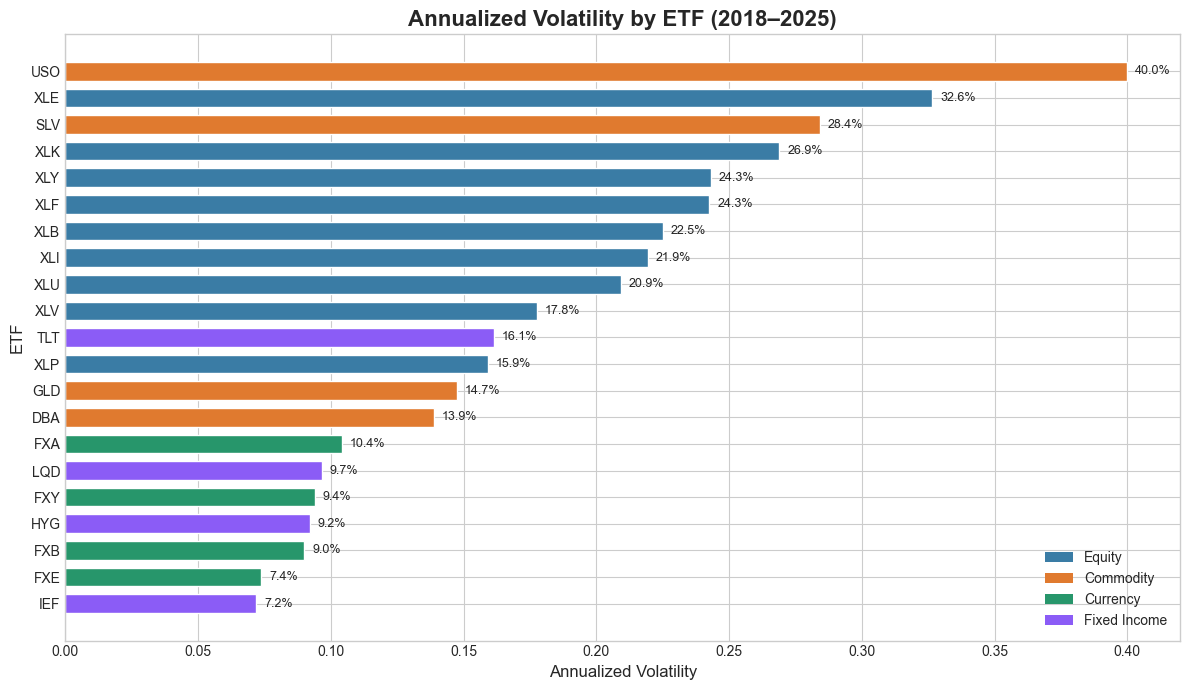

Most volatile: USO at 39.98% annualized
Least volatile: IEF at 7.18% annualized
Cross-sectional vol range: 32.80%


In [7]:
ann_vol = returns.std() * np.sqrt(252)
ann_vol_sorted = ann_vol.sort_values(ascending=True)

# Color by asset class
class_colors = {
    'Equity': '#3A7CA5',
    'Commodity': '#E07A2F',
    'Currency': '#27966B',
    'Fixed Income': '#8B5CF6',
}
asset_class_map = {}
for t in ['XLF','XLK','XLE','XLV','XLI','XLY','XLP','XLB','XLU']:
    asset_class_map[t] = 'Equity'
for t in ['GLD','SLV','USO','DBA']:
    asset_class_map[t] = 'Commodity'
for t in ['FXE','FXB','FXY','FXA']:
    asset_class_map[t] = 'Currency'
for t in ['TLT','IEF','HYG','LQD']:
    asset_class_map[t] = 'Fixed Income'

colors = [class_colors[asset_class_map[t]] for t in ann_vol_sorted.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(ann_vol_sorted.index, ann_vol_sorted.values, color=colors, edgecolor='white', height=0.7)
ax.set_title('Annualized Volatility by ETF (2018–2025)', fontsize=16, fontweight='bold')
ax.set_xlabel('Annualized Volatility', fontsize=12)
ax.set_ylabel('ETF', fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=lbl) for lbl, c in class_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

for i, (val, ticker) in enumerate(zip(ann_vol_sorted.values, ann_vol_sorted.index)):
    ax.text(val + 0.003, i, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Most volatile: {ann_vol_sorted.index[-1]} at {ann_vol_sorted.iloc[-1]:.2%} annualized')
print(f'Least volatile: {ann_vol_sorted.index[0]} at {ann_vol_sorted.iloc[0]:.2%} annualized')
print(f'Cross-sectional vol range: {ann_vol_sorted.iloc[-1] - ann_vol_sorted.iloc[0]:.2%}')

The volatility bar chart highlights a nearly 5x range in annualized risk across the universe. Commodity-linked ETFs like USO exhibit the highest volatility, while short-duration fixed-income instruments like IEF and LQD sit at the low end. This dispersion is important for two reasons. First, it means that pair spreads will have heterogeneous risk profiles, so volatility-targeted sizing is essential to prevent high-vol pairs from dominating the portfolio. Second, it confirms that the universe spans genuinely distinct risk regimes, which is a prerequisite for the MST to capture meaningful cross-asset connectivity rather than redundant within-cluster variation.

In numbers, USO runs at roughly 40% annualized volatility versus about 7% for IEF (with LQD still under 10%), so the cross-sectional spread in risk is on the order of 33 volatility points and the top-to-bottom ratio is well above 5×. Even within equities there’s meaningful dispersion — sector volatilities cluster in the ~18–27% range, with XLK nearer the high end (~27%) and defensives like XLV closer to the high teens — while long-duration rates (TLT ~16%) sit in a different band entirely from short-duration rates (IEF ~7%). That gap is exactly why naive equal-dollar sizing is misleading here: a single USO-linked position can swing as much as several low-vol positions combined, which will distort both portfolio risk and any attempt to evaluate edge-by-edge signal quality on the MST. Vol targeting makes the comparisons “apples-to-apples” by equalizing risk contributions rather than capital allocations.

### Graph 4: Rolling 126-Day Correlation Between Equity (XLK) and Fixed Income (TLT)

The MST topology strategy depends on *time-varying* relationships between assets. To illustrate that correlations are indeed unstable, we plot the rolling 126-day (half-year) correlation between XLK (technology equities) and TLT (long-duration Treasuries) — two assets that are typically negatively correlated but whose relationship has shifted meaningfully across recent regimes.

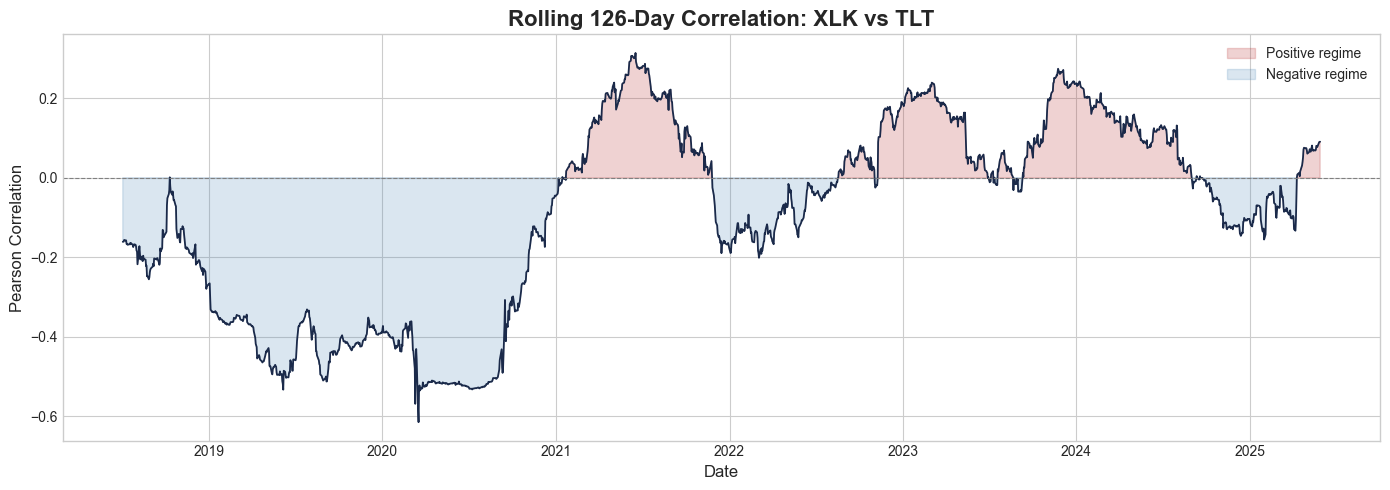

Share of sample where XLK-TLT correlation is positive: 42.45%
Correlation range: [-0.6145, 0.3140]
Full-sample correlation: -0.1229


In [8]:
rolling_corr = returns['XLK'].rolling(126).corr(returns['TLT'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_corr.index, rolling_corr.values, color='#1B2A4A', linewidth=1.3)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between(rolling_corr.index, rolling_corr.values, 0,
                where=rolling_corr.values > 0, alpha=0.2, color='firebrick', label='Positive regime')
ax.fill_between(rolling_corr.index, rolling_corr.values, 0,
                where=rolling_corr.values <= 0, alpha=0.2, color='steelblue', label='Negative regime')
ax.set_title('Rolling 126-Day Correlation: XLK vs TLT', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Pearson Correlation', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

pct_positive = (rolling_corr.dropna() > 0).mean()
print(f'Share of sample where XLK-TLT correlation is positive: {pct_positive:.2%}')
print(f'Correlation range: [{rolling_corr.min():.4f}, {rolling_corr.max():.4f}]')
print(f'Full-sample correlation: {returns["XLK"].corr(returns["TLT"]):.4f}')

The rolling correlation between technology equities and long-duration Treasuries swings between approximately -0.6 and +0.4 over our sample, spending substantial time in both positive and negative territory. This regime-switching behavior — driven by shifts between growth-scare environments (where stocks and bonds fall together) and risk-off flights (where bonds rally as stocks sell off) — is exactly what makes static correlation-based strategies fragile. The MST dynamically reconfigures as these relationships evolve, adapting which pairs are considered neighbors and therefore which dislocations are flagged as tradable signals.

Quantitatively, the 126-day correlation ranges from about −0.615 at its most negative to about +0.314 at its most positive, and it is actually positive roughly 42.5% of the time. That’s why the full-sample correlation of only −0.123 is misleading: it looks like a mild “stock–bond hedge” on average, but it’s really the net result of long stretches of negative correlation being partially offset by long stretches of positive correlation. In practical terms, if you built a strategy off the static average, you’d be implicitly assuming the relationship is consistently mildly negative — yet in nearly half the windows it flips sign, which is exactly when pair selection and hedge assumptions tend to break.

## 6. Data Formatting and Export

Finally, we verify the structure of the cached data files and confirm that the price panel is in the format needed for downstream MST construction and signal generation.

In [9]:
# Verify cached CSV structure
sample_csv = pd.read_csv(DATA_DIR / 'XLK.csv', parse_dates=['date'])
print('Sample cached CSV (XLK):')
print(f'  Columns: {list(sample_csv.columns)}')
print(f'  Rows: {len(sample_csv)}')
print(f'  Date range: {sample_csv["date"].min().date()} to {sample_csv["date"].max().date()}')
print()

# Verify the pivoted panel
print('Pivoted price panel:')
print(f'  Shape: {prices.shape}')
print(f'  Index type: {type(prices.index).__name__} (DatetimeIndex expected)')
print(f'  Column type: asset tickers — {prices.columns.tolist()[:5]} ...')
print(f'  Any NaN remaining: {prices.isna().any().any()}')
print()

# Data files on disk
cached_files = sorted(DATA_DIR.glob('*.csv'))
print(f'Cached CSV files in {DATA_DIR}/: {len(cached_files)}')
for f in cached_files:
    print(f'  {f.name}')

Sample cached CSV (XLK):
  Columns: ['date', 'close', 'ticker']
  Rows: 1862
  Date range: 2018-01-02 to 2025-05-29

Pivoted price panel:
  Shape: (1862, 21)
  Index type: DatetimeIndex (DatetimeIndex expected)
  Column type: asset tickers — ['DBA', 'FXA', 'FXB', 'FXE', 'FXY'] ...
  Any NaN remaining: False

Cached CSV files in data/: 22
  DBA.csv
  FXA.csv
  FXB.csv
  FXE.csv
  FXY.csv
  GLD.csv
  HYG.csv
  IEF.csv
  LQD.csv
  SLV.csv
  SPY.csv
  TLT.csv
  USO.csv
  XLB.csv
  XLE.csv
  XLF.csv
  XLI.csv
  XLK.csv
  XLP.csv
  XLU.csv
  XLV.csv
  XLY.csv


Each ticker is cached as a flat CSV with columns `[date, close, ticker]`. The `load_or_fetch_prices` function pivots these into a `date × ticker` panel with adjusted close prices as values. The panel is fully populated with no remaining NaN entries, which is required for the rolling correlation computation and MST construction that follows in the full analysis notebook.

## 7. Summary and Next Steps

This proposal notebook establishes the foundation for the MST Topology Trading project:

- We motivated the research question: whether temporary dislocations in the minimum spanning tree of cross-asset correlations predict short-horizon mean-reversion in relative returns.
- We summarized the academic literature that underpins the approach: Mantegna distance, dynamic MST analysis, effective resistance, and algebraic connectivity.
- We acquired and cached adjusted close prices for 21 ETFs across four asset classes from NASDAQ Data Link, covering January 2018 through December 2025.
- We verified data completeness, computed returns, and produced four exploratory graphs showing cumulative performance, correlation structure, volatility profiles, and time-varying correlation dynamics.

In the full project notebook, we will:

1. Construct rolling weekly MSTs and compute effective resistance for all node pairs.
2. Generate z-scored mean-reversion signals from resistance deviations and apply volatility-targeted pair sizing.
3. Simulate the strategy under both zero and realistic (5 bps/leg) transaction costs.
4. Analyze performance, drawdowns, tail risk, SPY correlation, and sensitivity to key parameters.
5. Compare results across cost regimes and stress periods to assess economic viability.